Building a Full Neural Network From Scratch

Step 1 — The dataset: XOR problem


XOR dataset:
  [0. 0.] → 0.0
  [0. 1.] → 1.0
  [1. 0.] → 1.0
  [1. 1.] → 0.0


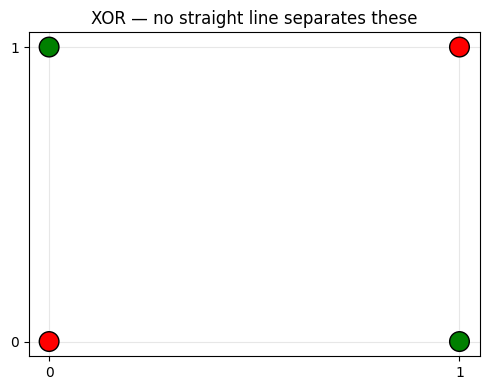

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# XOR — a classic problem that a single perceptron CANNOT solve
# but a 2-layer network can
# Input: [0,0] → 0,  [0,1] → 1,  [1,0] → 1,  [1,1] → 0

X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)
y = np.array([[0],[1],[1],[0]],         dtype=np.float32)

print("XOR dataset:")
for xi, yi in zip(X, y):
    print(f"  {xi} → {yi[0]}")

# Visualise — notice no straight line can separate the classes
plt.figure(figsize=(5, 4))
colors = ['red' if label == 0 else 'green' for label in y.flatten()]
plt.scatter(X[:,0], X[:,1], c=colors, s=200, edgecolors='black', zorder=5)
plt.title("XOR — no straight line separates these")
plt.xticks([0,1]); plt.yticks([0,1])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Step 2 — Activation functions and their derivatives


In [2]:
# We need the function AND its derivative for backprop
def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)   # 1 where z>0, 0 elsewhere

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))  # clip prevents overflow

def sigmoid_deriv(z):
    s = sigmoid(z)
    return s * (1 - s)

def binary_cross_entropy(y_pred, y_true):
    eps = 1e-15   # prevent log(0)
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Quick sanity checks
print("relu(-2, 0, 3)      :", relu(np.array([-2, 0, 3])))
print("relu_deriv(-2, 0, 3):", relu_deriv(np.array([-2, 0, 3])))
print("sigmoid(0)          :", sigmoid(0))    # should be 0.5
print("sigmoid(100)        :", sigmoid(100))  # should be ~1.0

relu(-2, 0, 3)      : [0 0 3]
relu_deriv(-2, 0, 3): [0. 0. 1.]
sigmoid(0)          : 0.5
sigmoid(100)        : 1.0


Step 3 — Network class: pure NumPy, full backprop


In [3]:
class NeuralNetworkFromScratch:
    """
    A 3-layer neural network (2 hidden + 1 output) built with pure NumPy.
    Architecture: input_size → 4 → 4 → 1
    Activations:  ReLU → ReLU → Sigmoid
    """

    def __init__(self, input_size, hidden_size, output_size, lr=0.1):
        self.lr = lr
        np.random.seed(42)

        # He initialisation — scale by sqrt(2/n_in) for ReLU layers
        # Prevents vanishing/exploding gradients (more on this Day 4)
        self.W1 = np.random.randn(hidden_size, input_size) * np.sqrt(2 / input_size)
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, hidden_size) * np.sqrt(2 / hidden_size)
        self.b2 = np.zeros((1, hidden_size))

        self.W3 = np.random.randn(output_size, hidden_size) * np.sqrt(2 / hidden_size)
        self.b3 = np.zeros((1, output_size))

    # ── FORWARD PASS ──────────────────────────────────────────────────────────
    def forward(self, X):
        """
        Store every Z and A — we need them in backprop.
        """
        # Layer 1
        self.Z1 = X @ self.W1.T + self.b1      # (n, hidden)
        self.A1 = relu(self.Z1)                  # (n, hidden)

        # Layer 2
        self.Z2 = self.A1 @ self.W2.T + self.b2 # (n, hidden)
        self.A2 = relu(self.Z2)                  # (n, hidden)

        # Output layer
        self.Z3 = self.A2 @ self.W3.T + self.b3 # (n, output)
        self.A3 = sigmoid(self.Z3)               # (n, output)

        return self.A3

    # ── BACKWARD PASS ─────────────────────────────────────────────────────────
    def backward(self, X, y):
        n = X.shape[0]   # batch size

        # ── Output layer ──
        # ∂L/∂Z3 = A3 - y   (combined BCE + sigmoid derivative simplifies nicely)
        dZ3 = self.A3 - y                        # (n, 1)
        dW3 = (dZ3.T @ self.A2) / n             # (output, hidden)
        db3 = dZ3.mean(axis=0, keepdims=True)   # (1, output)

        # ── Hidden layer 2 ──
        # Pass gradient back through W3, then through ReLU
        dA2 = dZ3 @ self.W3                      # (n, hidden)
        dZ2 = dA2 * relu_deriv(self.Z2)          # (n, hidden) — element-wise!
        dW2 = (dZ2.T @ self.A1) / n             # (hidden, hidden)
        db2 = dZ2.mean(axis=0, keepdims=True)   # (1, hidden)

        # ── Hidden layer 1 ──
        dA1 = dZ2 @ self.W2                      # (n, hidden)
        dZ1 = dA1 * relu_deriv(self.Z1)          # (n, hidden)
        dW1 = (dZ1.T @ X) / n                   # (hidden, input)
        db1 = dZ1.mean(axis=0, keepdims=True)   # (1, hidden)

        # ── Gradient descent update ──
        self.W3 -= self.lr * dW3
        self.b3 -= self.lr * db3
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    # ── TRAINING LOOP ─────────────────────────────────────────────────────────
    def train(self, X, y, epochs=5000, print_every=500):
        losses = []
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss   = binary_cross_entropy(y_pred, y)
            self.backward(X, y)
            losses.append(loss)

            if epoch % print_every == 0:
                acc = np.mean((y_pred > 0.5) == y) * 100
                print(f"Epoch {epoch:5d} | Loss: {loss:.4f} | Accuracy: {acc:.0f}%")

        return losses

    def predict(self, X):
        return (self.forward(X) > 0.5).astype(int)

Step 4 — Train and visualise


Epoch     0 | Loss: 0.7096 | Accuracy: 50%
Epoch   500 | Loss: 0.6931 | Accuracy: 50%
Epoch  1000 | Loss: 0.6931 | Accuracy: 50%
Epoch  1500 | Loss: 0.6931 | Accuracy: 50%
Epoch  2000 | Loss: 0.6931 | Accuracy: 50%
Epoch  2500 | Loss: 0.6931 | Accuracy: 50%
Epoch  3000 | Loss: 0.6931 | Accuracy: 50%
Epoch  3500 | Loss: 0.6931 | Accuracy: 50%
Epoch  4000 | Loss: 0.6931 | Accuracy: 50%
Epoch  4500 | Loss: 0.6931 | Accuracy: 50%

Final predictions on XOR:
  [0. 0.] → truth=0 pred=0 ✓
  [0. 1.] → truth=1 pred=0 ✗
  [1. 0.] → truth=1 pred=0 ✗
  [1. 1.] → truth=0 pred=0 ✓


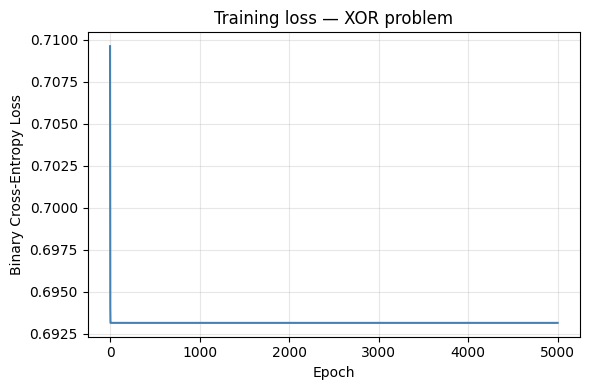

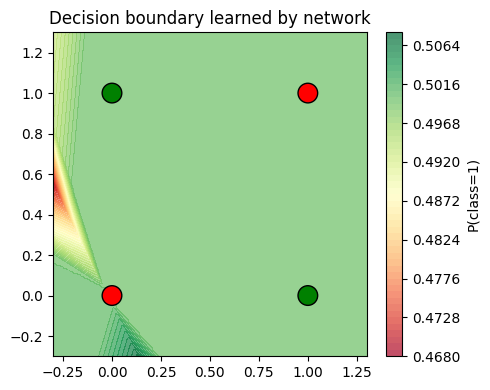

In [4]:
# Train on XOR
model = NeuralNetworkFromScratch(input_size=2, hidden_size=4, output_size=1, lr=0.5)
losses = model.train(X, y, epochs=5000, print_every=500)

print("\nFinal predictions on XOR:")
preds = model.predict(X)
for xi, yi, pi in zip(X, y, preds):
    status = "✓" if yi[0] == pi[0] else "✗"
    print(f"  {xi} → truth={int(yi[0])} pred={pi[0]} {status}")

# Plot loss curve
plt.figure(figsize=(6, 4))
plt.plot(losses, color='steelblue', linewidth=1.5)
plt.title("Training loss — XOR problem")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot decision boundary
xx, yy = np.meshgrid(np.linspace(-0.3, 1.3, 200),
                     np.linspace(-0.3, 1.3, 200))
grid   = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
Z      = model.forward(grid).reshape(xx.shape)

plt.figure(figsize=(5, 4))
plt.contourf(xx, yy, Z, levels=50, cmap='RdYlGn', alpha=0.7)
plt.colorbar(label='P(class=1)')
colors = ['red' if label == 0 else 'green' for label in y.flatten()]
plt.scatter(X[:,0], X[:,1], c=colors, s=200, edgecolors='black', zorder=5)
plt.title("Decision boundary learned by network")
plt.tight_layout()
plt.show()

💻 Part 4: Rebuild It in PyTorch — Same Results


Training PyTorch version...

Epoch     0 | Loss: 1.5678 | Accuracy: 50%
Epoch   500 | Loss: 0.0055 | Accuracy: 100%
Epoch  1000 | Loss: 0.0025 | Accuracy: 100%
Epoch  1500 | Loss: 0.0016 | Accuracy: 100%
Epoch  2000 | Loss: 0.0012 | Accuracy: 100%
Epoch  2500 | Loss: 0.0009 | Accuracy: 100%
Epoch  3000 | Loss: 0.0008 | Accuracy: 100%
Epoch  3500 | Loss: 0.0006 | Accuracy: 100%
Epoch  4000 | Loss: 0.0006 | Accuracy: 100%
Epoch  4500 | Loss: 0.0005 | Accuracy: 100%

Final predictions (PyTorch):
  [0. 0.] → truth=0 pred=0 ✓
  [0. 1.] → truth=1 pred=1 ✓
  [1. 0.] → truth=1 pred=1 ✓
  [1. 1.] → truth=0 pred=0 ✓


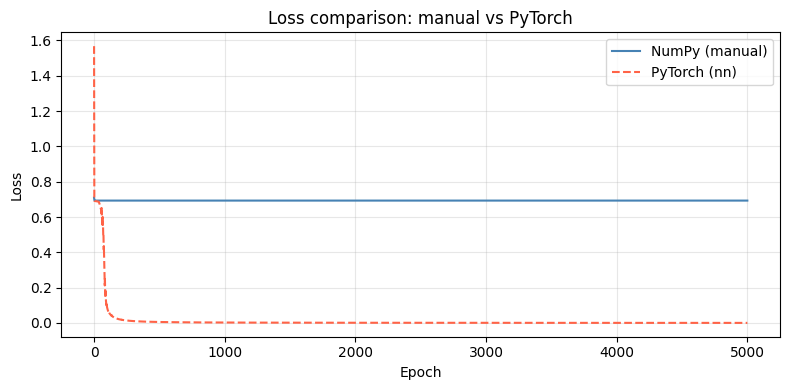

In [5]:
import torch
import torch.nn as nn

torch.manual_seed(42)

# Same data, converted to tensors
X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32)

# ── The PyTorch version ────────────────────────────────────────────────────
class NeuralNetTorch(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        # nn.Linear = W and b bundled together
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)
        self.relu    = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

        # He initialisation — match what we did manually
        nn.init.kaiming_normal_(self.fc1.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.fc2.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.fc3.weight, nonlinearity='relu')

    def forward(self, x):
        x = self.relu(self.fc1(x))    # hidden layer 1
        x = self.relu(self.fc2(x))    # hidden layer 2
        x = self.sigmoid(self.fc3(x)) # output
        return x

model_torch = NeuralNetTorch(2, 4, 1)
criterion   = nn.BCELoss()
optimizer   = torch.optim.SGD(model_torch.parameters(), lr=0.5)

print("Training PyTorch version...\n")
losses_torch = []

for epoch in range(5000):
    # 1. Forward
    y_pred = model_torch(X_t)
    loss   = criterion(y_pred, y_t)

    # 2. Zero grad
    optimizer.zero_grad()

    # 3. Backward
    loss.backward()

    # 4. Update
    optimizer.step()

    losses_torch.append(loss.item())
    if epoch % 500 == 0:
        acc = ((y_pred > 0.5) == y_t).float().mean() * 100
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.4f} | Accuracy: {acc:.0f}%")

# Final predictions
with torch.no_grad():
    final_preds = (model_torch(X_t) > 0.5).int()
    print("\nFinal predictions (PyTorch):")
    for xi, yi, pi in zip(X, y, final_preds):
        status = "✓" if int(yi[0]) == pi.item() else "✗"
        print(f"  {xi} → truth={int(yi[0])} pred={pi.item()} {status}")

# Compare loss curves
plt.figure(figsize=(8, 4))
plt.plot(losses,       label='NumPy (manual)',  linewidth=1.5, color='steelblue')
plt.plot(losses_torch, label='PyTorch (nn)',    linewidth=1.5, color='tomato', linestyle='--')
plt.title("Loss comparison: manual vs PyTorch")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Inspect what's inside a model


In [6]:
# Every interview will ask you to describe model parameters
print("── Model architecture ──")
print(model_torch)

print("\n── Parameter shapes ──")
for name, param in model_torch.named_parameters():
    print(f"  {name:20s}: shape={str(param.shape):20s} | requires_grad={param.requires_grad}")

total = sum(p.numel() for p in model_torch.parameters())
trainable = sum(p.numel() for p in model_torch.parameters() if p.requires_grad)
print(f"\nTotal parameters:     {total}")
print(f"Trainable parameters: {trainable}")

# Understand what nn.Linear actually stores
print("\n── fc1 weights and bias ──")
print("Weight shape:", model_torch.fc1.weight.shape)  # (hidden, input)
print("Bias shape:  ", model_torch.fc1.bias.shape)    # (hidden,)
print("Weight sample:\n", model_torch.fc1.weight.data[:2])

── Model architecture ──
NeuralNetTorch(
  (fc1): Linear(in_features=2, out_features=4, bias=True)
  (fc2): Linear(in_features=4, out_features=4, bias=True)
  (fc3): Linear(in_features=4, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

── Parameter shapes ──
  fc1.weight          : shape=torch.Size([4, 2])   | requires_grad=True
  fc1.bias            : shape=torch.Size([4])      | requires_grad=True
  fc2.weight          : shape=torch.Size([4, 4])   | requires_grad=True
  fc2.bias            : shape=torch.Size([4])      | requires_grad=True
  fc3.weight          : shape=torch.Size([1, 4])   | requires_grad=True
  fc3.bias            : shape=torch.Size([1])      | requires_grad=True

Total parameters:     37
Trainable parameters: 37

── fc1 weights and bias ──
Weight shape: torch.Size([4, 2])
Bias shape:   torch.Size([4])
Weight sample:
 tensor([[ 0.2184,  0.7987],
        [ 2.0315, -1.8681]])


Use nn.Sequential for simple networks


In [7]:
# For linear stacks, Sequential is even cleaner
model_seq = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)
print("Sequential model:\n", model_seq)
print("\nForward pass output shape:", model_seq(X_t).shape)

Sequential model:
 Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=4, bias=True)
  (3): ReLU()
  (4): Linear(in_features=4, out_features=1, bias=True)
  (5): Sigmoid()
)

Forward pass output shape: torch.Size([4, 1])


🔬 Part 5: Scale Up — Real Dataset


Epoch    0 | Train loss: 0.6852 acc: 58.4% | Test loss: 0.6658 acc: 83.0%
Epoch  200 | Train loss: 0.0643 acc: 97.5% | Test loss: 0.0420 acc: 99.0%
Epoch  400 | Train loss: 0.0587 acc: 97.8% | Test loss: 0.0400 acc: 99.0%
Epoch  600 | Train loss: 0.0573 acc: 97.8% | Test loss: 0.0402 acc: 99.0%
Epoch  800 | Train loss: 0.0567 acc: 97.8% | Test loss: 0.0397 acc: 99.0%


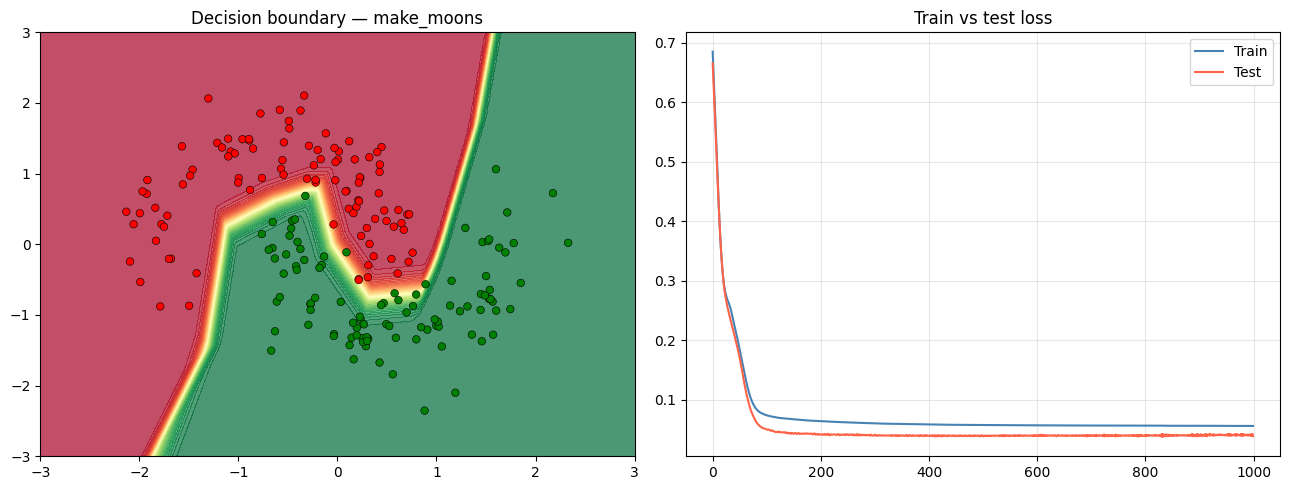

In [8]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# make_moons — two interleaved half-circles, not linearly separable
X_moons, y_moons = make_moons(n_samples=1000, noise=0.2, random_state=42)
y_moons = y_moons.reshape(-1, 1)

# Always normalise your data
scaler  = StandardScaler()
X_moons = scaler.fit_transform(X_moons).astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=42)

# Convert to tensors
X_tr = torch.tensor(X_train); y_tr = torch.tensor(y_train, dtype=torch.float32)
X_te = torch.tensor(X_test);  y_te = torch.tensor(y_test,  dtype=torch.float32)

# Bigger network for a harder problem
model_moons = nn.Sequential(
    nn.Linear(2, 16), nn.ReLU(),
    nn.Linear(16, 16), nn.ReLU(),
    nn.Linear(16, 1),  nn.Sigmoid()
)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model_moons.parameters(), lr=0.01)
# Adam instead of SGD — adapts learning rate per parameter (Day 4 topic)

train_losses, test_losses = [], []

for epoch in range(1000):
    model_moons.train()  # sets training mode (affects dropout/batchnorm)
    pred_tr = model_moons(X_tr)
    loss_tr = criterion(pred_tr, y_tr)
    optimizer.zero_grad()
    loss_tr.backward()
    optimizer.step()

    model_moons.eval()   # sets eval mode
    with torch.no_grad():
        pred_te  = model_moons(X_te)
        loss_te  = criterion(pred_te, y_te)

    train_losses.append(loss_tr.item())
    test_losses.append(loss_te.item())

    if epoch % 200 == 0:
        tr_acc = ((pred_tr > 0.5) == y_tr).float().mean() * 100
        te_acc = ((pred_te > 0.5) == y_te).float().mean() * 100
        print(f"Epoch {epoch:4d} | Train loss: {loss_tr:.4f} acc: {tr_acc:.1f}% "
              f"| Test loss: {loss_te:.4f} acc: {te_acc:.1f}%")

# Plot decision boundary on moons
xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
grid_t = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    Z = model_moons(grid_t).numpy().reshape(xx.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.contourf(xx, yy, Z, levels=50, cmap='RdYlGn', alpha=0.7)
colors = ['red' if l == 0 else 'green' for l in y_test.flatten()]
ax1.scatter(X_test[:,0], X_test[:,1], c=colors, s=30, edgecolors='black', linewidths=0.4)
ax1.set_title("Decision boundary — make_moons")

ax2.plot(train_losses, label='Train', color='steelblue')
ax2.plot(test_losses,  label='Test',  color='tomato')
ax2.set_title("Train vs test loss"); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()